In [1]:
import atom
import matplotlib.pyplot as plt
import potential
import torch
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

## Setup elements

In [2]:
elements = ["C", "Si", "Cu", "Au", "U"]

In [3]:
atomic_numbers = [atom.atom_number(el) for el in elements]

## Setup coordinates

In [26]:
n = 200
x = torch.linspace(-0.5, 0.5, n)
dx = x[1] - x[0]
y = x.clone()
z = x.clone()
X, Y, Z = torch.meshgrid(x, y, z, indexing="xy")
R = torch.sqrt(X**2 + Y**2 + Z**2)

## Compute 3D scattering potential
Note that potential.atomic_potential_3d inherently multiplies by the voxel size but Kirkland's Fig 5.5 does not. Hence we divide by the voxel size (dx**3) when plotting to match Kirkland's figure. In computations we have to include the voxel size for proper weighting.

![title](images/atomic-potential-3d-kirkland.png)

In [27]:
pots = []
for am in tqdm(atomic_numbers):
    pot3d = potential.atomic_potential_3d(am, R)
    pots.append(pot3d[n // 2, n // 2, n // 2 :])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.08it/s]


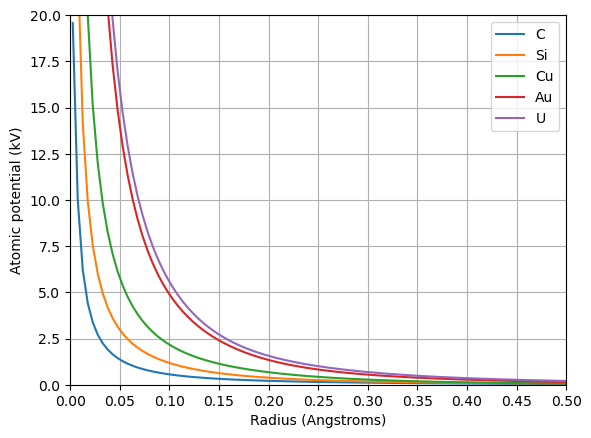

In [28]:
for i, pot in enumerate(pots):
    plt.plot(x[n // 2 :], pot / 1e3, label=elements[i])
    plt.xlabel("Radius (Angstroms)")
    plt.ylabel("Atomic potential (kV)")
plt.ylim(0, 20)
plt.xlim(0, 0.5)
plt.xticks(torch.linspace(0, 0.5, 11))
plt.grid()
plt.legend()

## Compute 2D scattering potential
Note that potential.atomic_potential_2d inherently multiplies by the voxel size but Kirkland's Fig 5.5 does not. Hence we divide by the voxel size (dx**3) when plotting to match Kirkland's figure. In computations we have to include the voxel size for proper weighting.

![title](images/projected-atomic-potential-2d-kirkland.png)

In [29]:
n = 800
x = torch.linspace(-0.5, 0.5, n)
dx = x[1] - x[0]
y = x.clone()
X, Y = torch.meshgrid(x, y, indexing="xy")
R_xy = torch.sqrt(X**2 + Y**2)

In [30]:
pots_2d = []
for am in tqdm(atomic_numbers):
    pot2d = potential.atomic_potential_2d(am, R_xy)
    pots_2d.append(pot2d[n // 2, n // 2 :])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.43it/s]


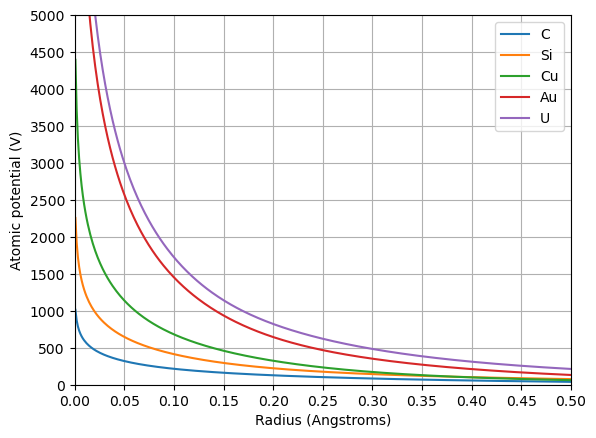

In [31]:
for i, pot in enumerate(pots_2d):
    plt.plot(x[n // 2 :], pot, label=elements[i])
    plt.xlabel("Radius (Angstroms)")
    plt.ylabel("Atomic potential (V)")
plt.ylim(0, 5000)
plt.xlim(0, 0.5)
plt.xticks(torch.linspace(0, 0.5, 11))
plt.yticks(torch.linspace(0, 5000, 11))
plt.grid()
plt.legend()

## Single atom images
Some minor discrepancies likely due to sampling/aliasing
![title](images/line-scan-transmission-kirkland.png)

In [10]:
rest_mass_energy = torch.tensor(511.0e3)  # [eV]
hc = torch.tensor(12.398e3)  # [eV * Å]


def energy_to_wavelength(energy):
    """Converts electron energy [keV] to wavelength [Å]"""
    ev = energy * 1e3
    return hc / torch.sqrt(ev * (ev + 2.0 * rest_mass_energy))


def interaction_parameter(energy):
    """Calculates the interaction parameter [1/ÅV]: Kirkland Eq.(5.6)."""
    w = energy_to_wavelength(energy)
    ev = energy * 1e3
    return (
        2.0
        * torch.pi
        / (w * ev)
        * ((ev + rest_mass_energy) / (ev + 2.0 * rest_mass_energy))
    )

In [11]:
energy = 200  # [keV]
wavelength = energy_to_wavelength(energy)
sigma = interaction_parameter(energy)

In [12]:
element_locations = [5, 15, 25, 35, 45]  # angstrom

In [43]:
n = 512
x = torch.linspace(0, 50, n)
dx = x[1] - x[0]
# x = torch.linspace(-25, 25, n)
y = torch.linspace(-25, 25, n) - dx / 2

In [14]:
pots_atom_2d = 0
for el, am in tqdm(zip(element_locations, atomic_numbers)):
    X, Y = torch.meshgrid(x, y, indexing="xy")
    R_xy = torch.sqrt((X - el) ** 2 + Y**2)
    pot2d = potential.atomic_potential_2d(am, R_xy)
    pots_atom_2d += pot2d

5it [00:01,  4.51it/s]


In [15]:
transmission = torch.exp(1j * sigma * pots_atom_2d)

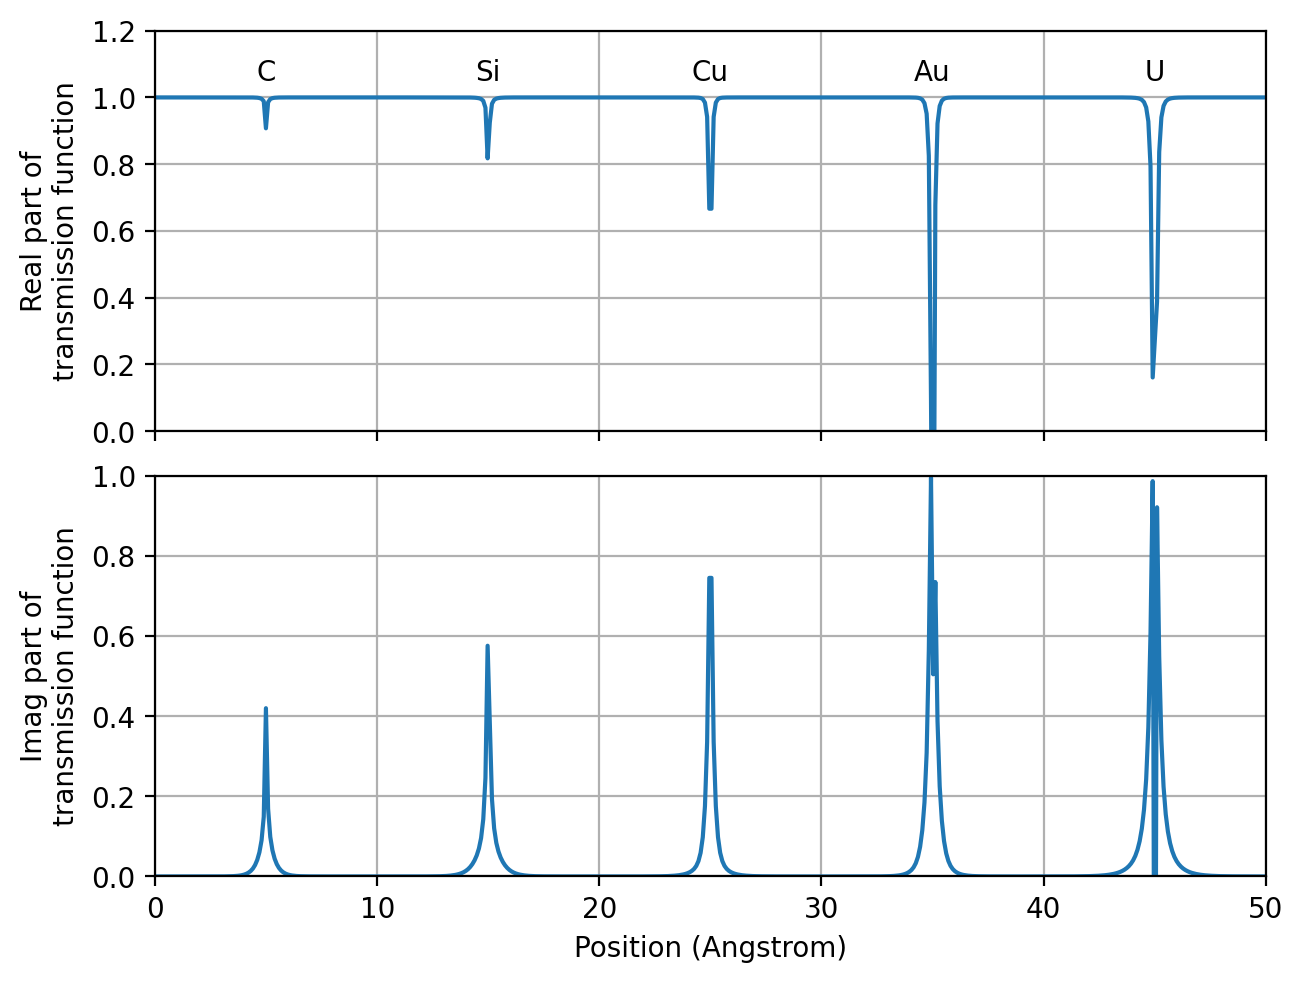

In [16]:
fig, axes = plt.subplots(2, 1, dpi=200, constrained_layout=True, sharex=True)
# real part
ax = axes[0]
ax.plot(x, torch.real(transmission[n // 2]))
for i, el in enumerate(element_locations):
    ax.text(el, 1.05, elements[i], ha="center")
ax.set_xlim(0, 50)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Real part of\ntransmission function")
ax.grid()

# imag part
ax = axes[1]
ax.plot(x, torch.imag(transmission[n // 2]))
ax.set_xlim(0, 50)
ax.set_ylim(0, 1)
ax.set_xlabel("Position (Angstrom)")
ax.set_ylabel("Imag part of\ntransmission function")
ax.grid()
plt.show()

## Coherent bright field phase contrast image
![title](images/coherent-bright-field-kirkland.png)
![title](images/coherent-bright-field-linescan-kirkland.png)

In [17]:
fft2 = lambda array: torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(array)))
ifft2 = lambda array: torch.fft.fftshift(torch.fft.ifft2(torch.fft.ifftshift(array)))

In [18]:
cs = 1.3e7  # [A]
df = 700  # [A]

kx = torch.fft.fftfreq(n, dx)
ky = torch.fft.fftfreq(n, dx)
kxx, kyy = torch.meshgrid(kx, ky, indexing="ij")
kxx = torch.fft.fftshift(kxx)
kyy = torch.fft.fftshift(kyy)
k2 = kxx**2 + kyy**2
k = torch.sqrt(k2)

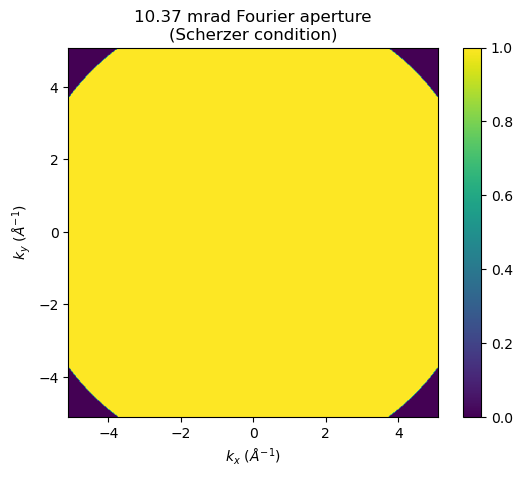

In [62]:
plt.figure(dpi=100)
plt.imshow(
    k_aperture, extent=[torch.min(kx), torch.max(kx), torch.min(kx), torch.max(kx)]
)
plt.xlabel('$k_x$ ($\AA^{-1}$)')
plt.ylabel('$k_y$ ($\AA^{-1}$)')
plt.title("10.37 mrad Fourier aperture\n(Scherzer condition)")
plt.colorbar()
plt.show()

In [21]:
gamma = torch.pi * wavelength * k2 * (0.5 * cs * wavelength**2 * k2 - df)

In [22]:
propagated = ifft2(fft2(transmission) * torch.exp(-1j * gamma) * k_aperture)

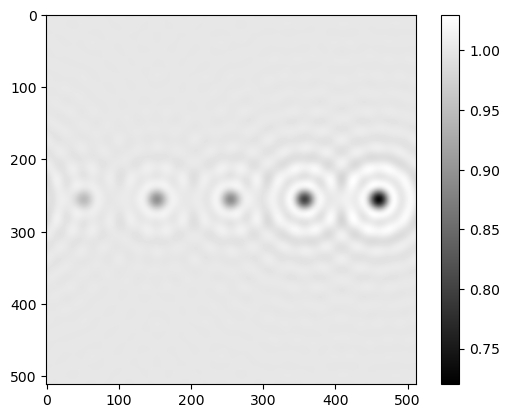

In [32]:
plt.imshow(torch.abs(propagated**2), cmap="grey", vmin=0.72, vmax=1.03)
plt.colorbar()

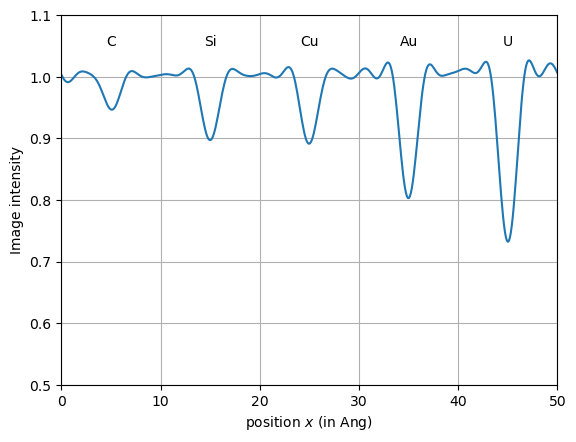

In [47]:
plt.plot(x, torch.abs(propagated**2)[256,:])
for i, el in enumerate(element_locations):
    plt.text(el, 1.05, elements[i], ha="center")
plt.xlim([x[0],x[-1]])
plt.ylim([0.5, 1.1])
plt.ylabel('Image intensity')
plt.xlabel('position $x$ (in Ang)')
plt.grid()